<h1 style="color:#1f77b4; font-family:'Times New Roman';">
<b>SVM From Scratch</b>
</h1>
<div style="font-family:'Times New Roman';">
<b>Goal:</b>
<ol>
<li>Implement a Support Vector Machine without using any ML libraries.</li>
<li>Understand the math behind the hinge loss and gradient descent.</li>
<li>Train the model on synthetic data and visualize the learned hyperplane.</li>
<li>Compare it with what we visualized in the previous notebook.</li>
</ol>
In the previous notebook, I manually drew the hyperplane and margin. 
Now, I'll write the actual algorithm that <b>learns</b> these values from data.
</div>

In [1]:
# Only numpy for math and matplotlib for visualization

import numpy as np
import matplotlib.pyplot as plt

In [2]:
# geberating synthetic daata
np.random.seed(42)

class_neg = np.random.randn(20, 2) + np.array([2, 2])
class_pos = np.random.randn(20, 2) + np.array([6, 6])
X = np.vstack((class_neg, class_pos))

# Labels: -1 for class_neg, +1 for class_pos
y = np.array([-1]*20 + [1]*20)

print("Data shape:", X.shape)
print("Labels shape:", y.shape)

Data shape: (40, 2)
Labels shape: (40,)


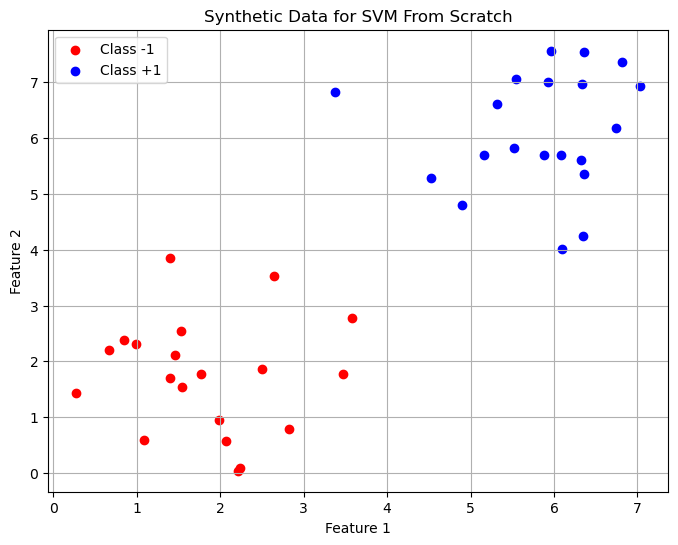

In [3]:
# plotting the data
plt.figure(figsize=(8, 6))
plt.scatter(class_neg[:, 0], class_neg[:, 1], color='red', label='Class -1')
plt.scatter(class_pos[:, 0], class_pos[:, 1], color='blue', label='Class +1')

plt.title("Synthetic Data for SVM From Scratch")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>The Math: Hinge Loss and Gradient Descent</b>
</h2>
<div style="font-family:'Times New Roman';">
SVM tries to find <b>w</b> and <b>b</b> such that the hyperplane 
<b>w · x + b = 0</b> separates the classes with the maximum margin.
<br><br>
To do this, we minimize the following objective function:
<br><br>
<b>J = λ ||w||² + (1/n) Σ max(0, 1 - yᵢ(w · xᵢ + b))</b>
<br><br>
Let's break this down:
<ul>
<li><b>λ ||w||²</b> -> This is the regularization term. It tries to keep 
<b>w</b> small, which in turn makes the margin as wide as possible.</li>
<li><b>max(0, 1 - yᵢ(w · xᵢ + b))</b> -> This is the <b>hinge loss</b>. 
It's zero if a point is correctly classified and outside the margin. 
If a point is inside the margin or misclassified, this term becomes 
positive and penalizes the model.</li>
</ul>
We minimize this using <b>gradient descent</b> - updating <b>w</b> and 
<b>b</b> step by step in the direction that reduces the loss.
<br><br>
The update rules are:
<ul>
<li>If <b>yᵢ(w · xᵢ + b) ≥ 1</b> (point correctly classified, outside margin):
<br>w = w - learning_rate * (2 * λ * w)</li>
<li>If <b>yᵢ(w · xᵢ + b) < 1</b> (point inside margin or misclassified):
<br>w = w - learning_rate * (2 * λ * w - yᵢ * xᵢ)
<br>b = b - learning_rate * (-yᵢ)</li>
</ul>
</div>

In [ ]:
class SVM:
    """
    A simple linear SVM implemented from scratch using gradient descent
    on the hinge loss.
    """

    def __init__(self, learning_rate=0.001, lambda_param=0.01, n_iters=1000):
        # learning_rate : how big a step we take during gradient descent
        # lambda_param : regularization strength (controls margin width)
        # n_iters : number of times we go through the entire dataset
        self.lr = learning_rate
        self.lambda_param = lambda_param
        self.n_iters = n_iters
        self.w = None
        self.b = None

    def fit(self, X, y):
        n_samples, n_features = X.shape

        # Initializing weights and bias to zero
        self.w = np.zeros(n_features)
        self.b = 0

        # Gradient descent loop
        for _ in range(self.n_iters):
            for idx, x_i in enumerate(X):

                # Checking the SVM condition: y_i * (w.x_i + b) >= 1
                condition = y[idx] * (np.dot(x_i, self.w) + self.b) >= 1

                if condition:
                    # Point is correctly classified and outside the margin
                    # Only the regularization term affects the gradient
                    dw = 2 * self.lambda_param * self.w
                    db = 0
                else:
                    # Point is inside the margin or misclassified
                    # Both regularization and hinge loss affect the gradient
                    dw = 2 * self.lambda_param * self.w - np.dot(x_i, y[idx])
                    db = -y[idx]

                # Updating weights and bias
                self.w -= self.lr * dw
                self.b -= self.lr * db

    def predict(self, X):
        # The sign of (w.x + b) tells us which side of the hyperplane
        # a point lies on -> that's our predicted class
        linear_output = np.dot(X, self.w) + self.b
        return np.sign(linear_output)

    def decision_function(self, X):
        # Returns the raw value of w.x + b (useful for plotting)
        return np.dot(X, self.w) + self.b

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Training the Model</b>
</h2>
<div style="font-family:'Times New Roman';">
Now let's create an instance of our SVM class and train it on the 
synthetic data. The model will learn the values of <b>w</b> and 
<b>b</b> that define the hyperplane.
</div>

In [5]:
# Creating and training the SVM model
model = SVM(learning_rate=0.001, lambda_param=0.01, n_iters=1000)
model.fit(X, y)

# Printing the learned parameters
print("Learned weights (w):", model.w)
print("Learned bias (b):", model.b)

Learned weights (w): [0.45012533 0.44829227]
Learned bias (b): -3.340999999999743


<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Visualizing the Learned Hyperplane</b>
</h2>
<div style="font-family:'Times New Roman';">
Now plotting the data along with the hyperplane and margins that our 
model learned on its own - no manual tuning this time!
<br><br>
Just like before:
<ul>
<li>The solid line is the <b>hyperplane</b>: w.x + b = 0</li>
<li>The dashed lines are the <b>margins</b>: w.x + b = 1 and w.x + b = -1</li>
</ul>
</div>

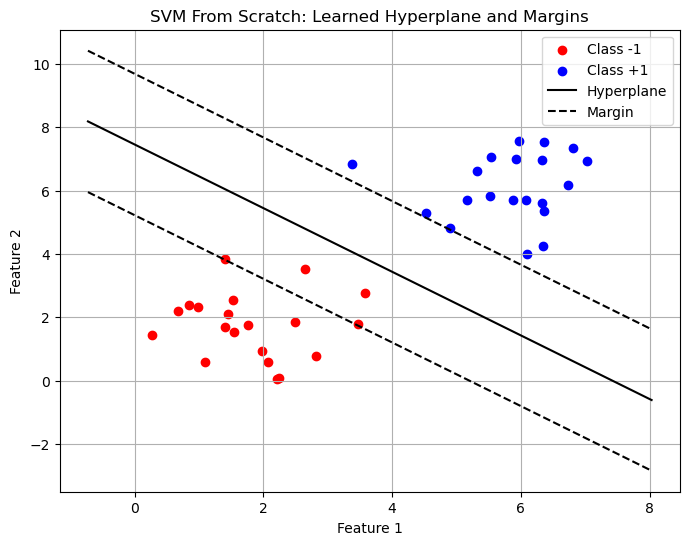

In [6]:
def plot_svm(X, y, model):
    plt.figure(figsize=(8, 6))

    # Plotting the two classes
    plt.scatter(X[y == -1][:, 0], X[y == -1][:, 1], color='red', label='Class -1')
    plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='blue', label='Class +1')

    # Getting the learned weights and bias
    w = model.w
    b = model.b

    # x1 range for plotting lines
    x1 = np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 50)

    # Hyperplane: w0*x1 + w1*x2 + b = 0  ->  x2 = -(w0*x1 + b)/w1
    x2_hyperplane = -(w[0] * x1 + b) / w[1]

    # Margins: w0*x1 + w1*x2 + b = 1 and = -1
    x2_margin_pos = -(w[0] * x1 + (b - 1)) / w[1]
    x2_margin_neg = -(w[0] * x1 + (b + 1)) / w[1]

    # Plotting hyperplane and margins
    plt.plot(x1, x2_hyperplane, color='black', label='Hyperplane')
    plt.plot(x1, x2_margin_pos, 'k--', label='Margin')
    plt.plot(x1, x2_margin_neg, 'k--')

    plt.title("SVM From Scratch: Learned Hyperplane and Margins")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.legend()
    plt.grid(True)
    plt.show()


plot_svm(X, y, model)

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Checking Predictions and Accuracy</b>
</h2>
<div style="font-family:'Times New Roman';">
Now let's use our trained model to make predictions on the same data 
and check how many points it classifies correctly. Since our data 
is clearly separable, we should expect high (or perfect) accuracy.
</div>

In [7]:
# Making predictions on the training data
predictions = model.predict(X)

# Calculating accuracy
accuracy = np.mean(predictions == y)

print("Predictions:", predictions)
print("Actual Labels:", y)
print(f"Accuracy: {accuracy * 100:.2f}%")

Predictions: [-1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.
 -1. -1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.
  1.  1.  1.  1.]
Actual Labels: [-1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1]
Accuracy: 100.00%


<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Identifying Support Vectors</b>
</h2>
<div style="font-family:'Times New Roman';">
Remember, support vectors are the points closest to the hyperplane - 
the ones that lie near or on the margin lines. We can find them by 
checking how close each point's decision value is to 1 or -1.
</div>

Number of support vectors found: 6


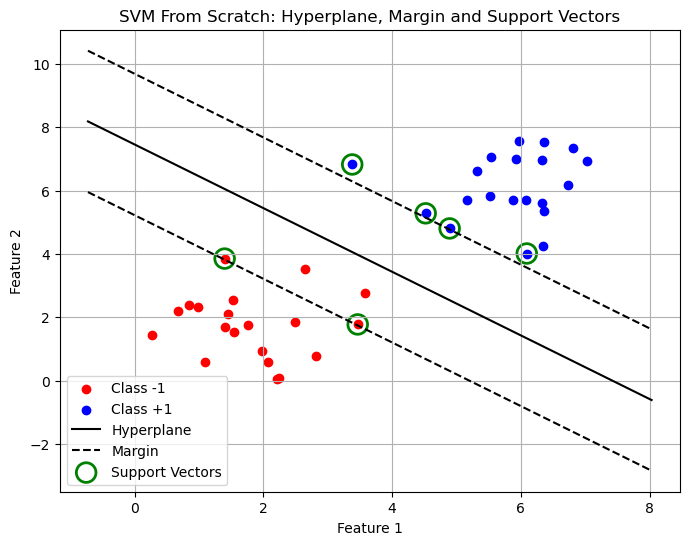

In [8]:
# Calculating decision function values for all points
decision_values = model.decision_function(X)

# Points close to the margin (|decision value| close to 1) are support vectors
# Using a small threshold to find "near-margin" points
threshold = 0.3
support_vector_indices = np.where(np.abs(np.abs(decision_values) - 1) < threshold)[0]

support_vectors = X[support_vector_indices]
print("Number of support vectors found:", len(support_vectors))

# Plotting everything together
plt.figure(figsize=(8, 6))
plt.scatter(X[y == -1][:, 0], X[y == -1][:, 1], color='red', label='Class -1')
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='blue', label='Class +1')

w = model.w
b = model.b
x1 = np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 50)
x2_hyperplane = -(w[0] * x1 + b) / w[1]
x2_margin_pos = -(w[0] * x1 + (b - 1)) / w[1]
x2_margin_neg = -(w[0] * x1 + (b + 1)) / w[1]

plt.plot(x1, x2_hyperplane, color='black', label='Hyperplane')
plt.plot(x1, x2_margin_pos, 'k--', label='Margin')
plt.plot(x1, x2_margin_neg, 'k--')

# Highlighting support vectors
plt.scatter(support_vectors[:, 0], support_vectors[:, 1],
            s=200, facecolors='none', edgecolors='green',
            linewidths=2, label='Support Vectors')

plt.title("SVM From Scratch: Hyperplane, Margin and Support Vectors")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Summary</b>
</h2>
<div style="font-family:'Times New Roman';">
<ul>
<li>Implemented SVM from scratch using <b>hinge loss</b> and 
<b>gradient descent</b> - no ML libraries used!</li>
<li>The model learned <b>w</b> and <b>b</b> on its own to find a 
separating hyperplane.</li>
<li>The <b>regularization term (λ ||w||²)</b> controls how wide the margin is - 
a smaller λ allows a wider margin but may tolerate more misclassification.</li>
<li>Visualized the learned hyperplane, margins, and support vectors - 
matching the intuition built in the previous notebook.</li>
</ul>
Next, I can experiment with different values of <b>λ</b> and 
<b>learning rate</b> to see how they affect the margin width and 
the model's behavior on slightly overlapping data.
</div>